In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'
from tqdm import tqdm

from joblib import Parallel, delayed

import pickle

import schwingerModel as sim

import scipy.sparse as sparse

In [2]:
def coshCorrel(nt, Energy, pivot,dimt):
    num = np.exp(-nt*Energy)+np.exp((nt-dimt)*Energy)
    denom = np.exp(-pivot*Energy)+np.exp((pivot-dimt)*Energy)
    return num/denom

In [36]:
with open('configs/50kSteps.pkl', 'rb') as f:
    a1 = pickle.load(f)

In [39]:
sim.distillation.generateDistillFile(modelObj=a1,filePath="./configs/50kSteps.hdf5",numVecs=7,autocorrSkip=50,DNums=(0,2))

Generating distill data:   0%|          | 0/1000 [00:00<?, ?it/s]

'./configs/50kSteps.hdf5'

In [40]:
basis = [sim.distillation.MesonOp("g5"),sim.distillation.MesonOp("g5",DNum=2)]
corrs = sim.GEVP.measureEnsemble2pt("./configs/50kSteps.hdf5",np.arange(0,50000,50),basis=basis)

In [41]:
gevpOut = sim.GEVP.bootstrapEnsemble2pt(corrs,reduce=sim.GEVP.gevpReduce)

In [53]:
ti = 3

m0 = sim.correlation.gevpMassExtract(gevpOut,fitT=[ti,6],eigenIdx=0)
m1 = sim.correlation.gevpMassExtract(gevpOut,fitT=[ti,6],eigenIdx=1)

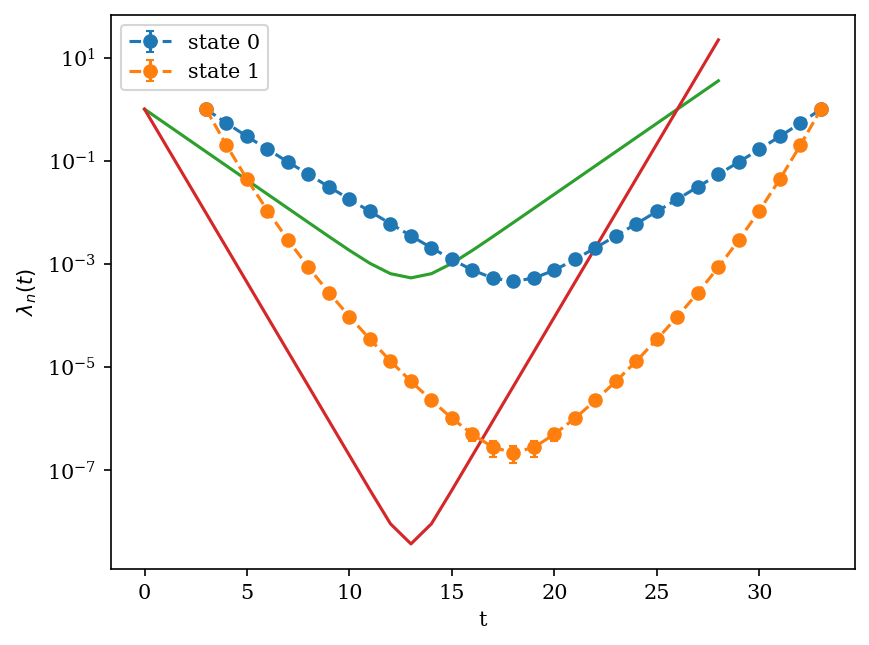

In [55]:
central, err, cov = gevpOut

ts = np.arange(ti, ti + central.shape[0])          # gevp curves start at ti

plt.figure(dpi=150)
for e in range(central.shape[1]):
    plt.errorbar(ts, central[:, e], yerr=err[::-1, :, e],
                 fmt='o--', capsize=2, label=f"state {e}")
plt.semilogy()
plt.xlabel("t"); plt.ylabel(r"$\lambda_n(t)$")
plt.legend()

plt.plot(coshCorrel(np.arange(ti,a1.dimt),m0[0],ti,a1.dimt))
plt.plot(coshCorrel(np.arange(ti,a1.dimt),m1[0],ti,a1.dimt))

[]

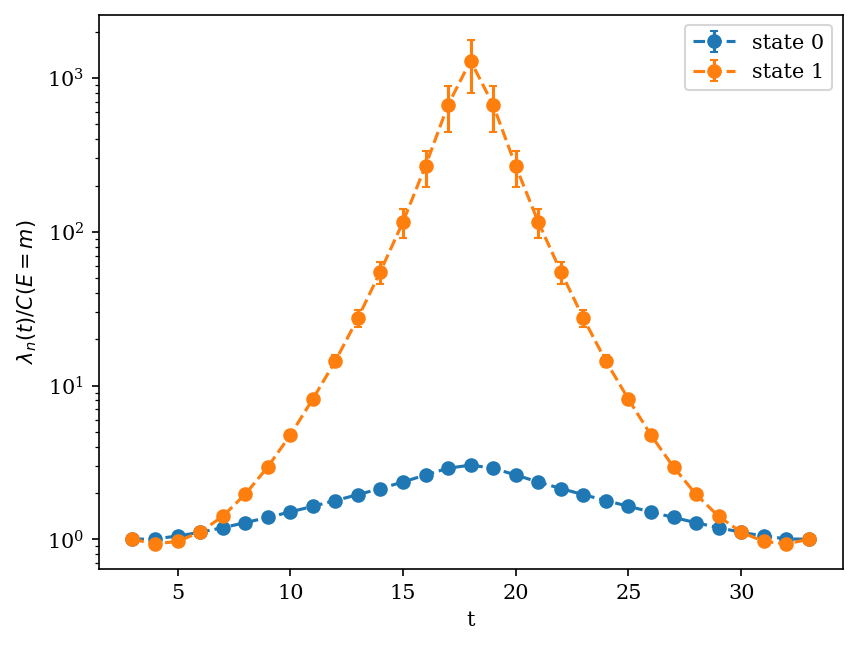

In [56]:
fits = [coshCorrel(np.arange(1,a1.dimt),m0[0],1,a1.dimt),coshCorrel(np.arange(1,a1.dimt),m1[0],1,a1.dimt)]

plt.figure(dpi=150)
for e in range(central.shape[1]):
    plt.errorbar(ts, central[:, e]/fits[e], yerr=err[::-1, :, e]/fits[e],
                 fmt='o--', capsize=2, label=f"state {e}")
plt.xlabel("t"); plt.ylabel(r"$\lambda_n(t)/C(E=m)$")
plt.legend()
plt.semilogy()